# Exercise 7

In [ ]:
import math
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import random

## Part 1

In [2]:
m = 10
n = [x for x in range(m)]

In [4]:
def cost(p1,p2):
    return math.dist(p1,p2)

def route_swap(n):
    choice1 = int(np.random.uniform(len(n)))
    choice2 = int(np.random.uniform(len(n)))    

    while choice1 == choice2:
        choice2 = int(np.random.uniform(len(n)))

    n_swap = n.copy()

    n_swap[choice1] = n[choice2]
    n_swap[choice2] = n[choice1]

    return n_swap

#def route_shuffle(n):
    n_shuffled = random.shuffle(n)
    return n_shuffled

def cooling1(n_T):
    T = []
    for k in range(n_T):
        T.append(1/math.sqrt(1+k))

    return T

def cooling2(n_T):
    T = []
    for k in range(n_T):
        T.append(1/math.log(2+k))

    return T

def f_Eu(n):
    angles = np.linspace(0, 2*np.pi, len(n), endpoint=False)
    points = np.column_stack((np.cos(angles), np.sin(angles)))

    cost_sum = 0
    for i in range(len(n)):
        if i == len(n)-1:
            cost_sum += cost(points[n[i]],points[n[0]])
        else:
            cost_sum += cost(points[n[i]],points[n[i+1]])
        
    return cost_sum

def a(x,y,T):
    result = min(1,np.exp(-(f(y)-f(x))/T))
    return result

def TSP(n,n_T):
    result = []
    x = n.copy()
    for i in range(n_T):
        y = route_swap(x)
        T = cooling(n_T)[i]
        accept_rate = a(x,y,T)
        choice = np.random.uniform(0,1)

        if choice <= accept_rate:
            result = y
            x = y
        else:
            result = x

    return result



In [6]:
#Test function
n_T = 10
reps = 10
cooling = cooling1
f = f_Eu

routes = []
costs = []
for i in range(reps):
    route = TSP(n,n_T)
    routes.append(route)
    costs.append(f(route))

print("routes:",routes)
print("costs:",costs)



routes: [[0, 1, 2, 3, 4, 5, 6, 7, 8, 9], [0, 1, 3, 2, 4, 5, 6, 7, 8, 9], [0, 1, 2, 3, 4, 5, 6, 7, 8, 9], [0, 1, 2, 3, 4, 5, 6, 7, 8, 9], [0, 1, 2, 3, 4, 5, 6, 7, 8, 9], [0, 1, 2, 3, 4, 5, 6, 7, 8, 9], [0, 1, 2, 3, 4, 5, 6, 7, 8, 9], [0, 1, 2, 3, 4, 5, 6, 7, 8, 9], [0, 1, 2, 3, 4, 5, 6, 7, 8, 9], [0, 1, 3, 2, 4, 5, 6, 7, 8, 9]]
costs: [6.180339887498949, 7.295412919169052, 6.180339887498949, 6.180339887498949, 6.180339887498949, 6.180339887498949, 6.180339887498949, 6.180339887498949, 6.180339887498949, 7.295412919169052]


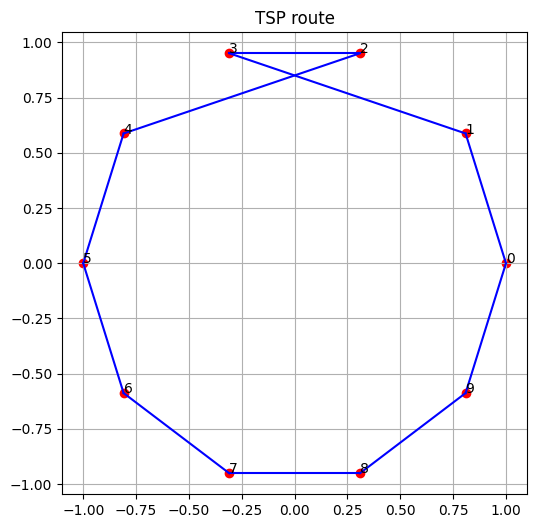

In [7]:
route = TSP(n,n_T)

angles = np.linspace(0, 2*np.pi, m, endpoint=False)
points = np.column_stack((np.cos(angles), np.sin(angles)))

plt.figure(figsize=(6,6))
plt.scatter(points[:,0], points[:,1], color='red')

for i, (x, y) in enumerate(points):
    plt.text(x, y, str(i))

closed_route = route + [route[0]]

for i in range(len(closed_route)-1):
    p1 = points[closed_route[i]]
    p2 = points[closed_route[i+1]]
    plt.plot([p1[0], p2[0]],
             [p1[1], p2[1]],
             'b-')

plt.title("TSP route")
plt.grid(True)
plt.show()


## Part 2

In [8]:
M_cost = np.loadtxt(open("cost.csv", "rb"), delimiter=",")

m,_ = M_cost.shape

n = [x for x in range(m)]

In [9]:
def a(x,y,T): #New a to prevent "RuntimeWarning: overflow encountered in exp result = min(1,np.exp(-(f(y)-f(x))/T))""
    delta = f(y)-f(x)
    if delta <= 0:
        p = 1.0
    else:
        p = np.exp(-delta/T)
    return p

def f_M(n):
    cost_sum = 0
    for i in range(len(n)):
        if i == len(n)-1:
            cost_sum += M_cost[n[i],n[0]]
        else:
            cost_sum += M_cost[n[i],n[i+1]]
        
    return cost_sum

In [10]:
#Test function
n_T = 10
reps = 10
f = f_M
cooling = cooling1

routes = []
costs = []
for i in range(reps):
    route = TSP(n,n_T)
    routes.append(route)
    costs.append(f_M(route))

print("routes:",routes)
print("costs:",costs)


routes: [[0, 1, 2, 6, 7, 5, 3, 4, 8, 9, 10, 19, 12, 18, 14, 13, 16, 17, 15, 11], [0, 10, 2, 3, 4, 5, 7, 1, 8, 9, 15, 11, 12, 13, 14, 18, 16, 17, 6, 19], [0, 2, 12, 3, 4, 5, 6, 7, 9, 17, 10, 11, 1, 13, 14, 15, 16, 8, 18, 19], [0, 18, 2, 3, 4, 5, 7, 1, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 6, 19], [0, 6, 12, 3, 19, 5, 11, 14, 8, 9, 1, 10, 2, 13, 4, 15, 16, 17, 18, 7], [0, 12, 2, 3, 4, 5, 6, 17, 8, 9, 7, 1, 18, 13, 14, 15, 16, 10, 11, 19], [0, 10, 2, 3, 4, 5, 6, 7, 8, 9, 1, 11, 19, 13, 14, 15, 16, 17, 18, 12], [0, 1, 2, 3, 16, 5, 6, 11, 17, 7, 9, 10, 12, 13, 14, 15, 4, 8, 18, 19], [0, 1, 15, 3, 5, 4, 6, 7, 13, 9, 18, 11, 12, 8, 14, 2, 16, 17, 10, 19], [0, 5, 11, 3, 8, 1, 6, 7, 4, 9, 10, 19, 12, 13, 14, 15, 16, 2, 18, 17]]
costs: [np.float64(2919.0), np.float64(2083.0), np.float64(2828.0), np.float64(2828.0), np.float64(2387.0), np.float64(2135.0), np.float64(2828.0), np.float64(2553.0), np.float64(2616.0), np.float64(2452.0)]
